# Raman Fitting Example: Bi-layer Graphene

This example shows Raman fitting for bi-layer graphene Raman spectrum. The spectrum contains multiple overlapping peaks, including the G peak and the 2D peak, which can be deconvoluted using multiple Lorentzian functions. We will demonstrate how to set up the fitting process using the `RamanFit` class from the `RamanPL_2D` package with appropriate background removal and peak fitting.


## 1. Using `poly` baseline method for background removal

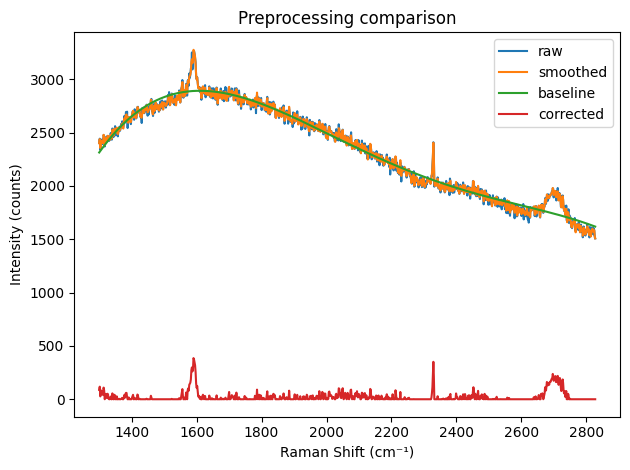


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.64         13.30         369.06         6.65      
2D-1B                2600.00         20.00         0.00           10.00     
2D-1A                2650.00         20.00         2.32           10.00     
2D-2A                2694.64         20.00         224.23         10.00     
2D-2B                2716.22         16.89         145.30         8.45      

Normalized Residual: 0.2860 (0 = perfect fit)


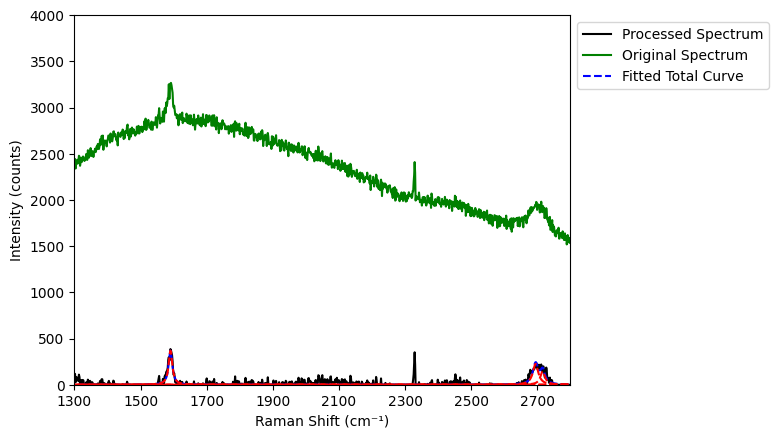

In [1]:
from ramanpl import RamanFit

# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    # readlines=[0, 1012]                         # Deprected: Read all data lines
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(spectra, wavenumber,
                     materials=['2L-Gr'],      # Load materials; here we have "Gr" for graphene and "2L-Gr" for bilayer graphene, 
                                               # their component peaks in 2D curve differ significantly
                     substrate=None,           # Here the sample is loaded on Cu, which has no Raman spectra due to lack of polarisablity
                     normalize=False,           # Normalize your peak intensity, if needed
                     background_remove=True,   # If your Raman contains needs remove background intensity, use this
                     baseline_method=("poly", 4), # Method to remove background, here we use polynomial fitting with degree 3, you can also use "asymmetric_least_squares" or "rolling_ball"
                     smoothing=True,           # Smooth too noisy signal, only if needed
                     smooth_order=8            # smooth_order in range 1 to 10, where 1 means the strongest smooth
                     )

# Update the fitting bounds 
bounds_dict = {
    '2D-1B':  ([2600, 0, 0], [2620, 10, 10]),
    '2D-1A':  ([2620, 0, 0], [2650, 10, 20]),
    '2D-2A':  ([2650, 0, 0], [2700, 10, 20]),
    '2D-2B':  ([2700, 0, 0], [2720, 10, 10]),

}
raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )

## 2. Using `asls` baseline method for background removal

The next cell will demonstrate background subtraction using `arpls` method (a.ka.a. "adaptive reweighted penalized least squares"). This method is more advanced and generally provides better baseline correction for Raman spectra with complex backgrounds.

Tuning rules:

- Baseline still “wavy” / tracking peaks → increase lam (e.g., 1e8, 1e9)

- Baseline too stiff / not removing curvature → decrease lam (e.g., 1e6)

- Baseline too high (eats peak foot) → decrease p (e.g., 0.005)

- Baseline too low → increase p (e.g., 0.02)

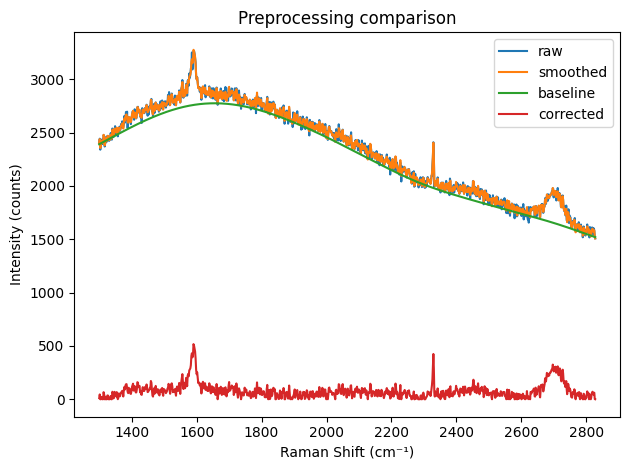


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.22         16.10         408.56         8.05      
2D-1B                2600.00         20.00         34.61          10.00     
2D-1A                2650.00         20.00         106.13         10.00     
2D-2A                2695.79         20.00         327.90         10.00     
2D-2B                2720.00         18.65         176.49         9.32      

Normalized Residual: 0.4908 (0 = perfect fit)


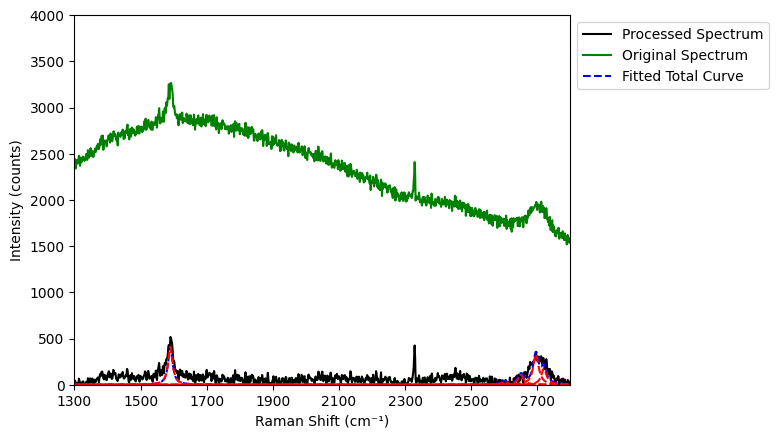

In [2]:
from ramanpl import RamanFit

# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

baseline_setting={"method": "asls", "lam": 1e6, "p": 0.01, "niter": 30}

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method={"method": "asls", "lam": 1e6, "p": 0.01, "niter": 30},
    smoothing=True,
    smooth_order=8
)

# Update the fitting bounds 
bounds_dict = {
    '2D-1B':  ([2600, 0, 0], [2620, 10, 10]),
    '2D-1A':  ([2620, 0, 0], [2650, 10, 20]),
    '2D-2A':  ([2650, 0, 0], [2700, 10, 20]),
    '2D-2B':  ([2700, 0, 0], [2720, 10, 10]),

}
raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )

## 3. Using `arpls` baseline method for background removal
The cell below will demonstrate background subtraction using `arpls` method (a.ka.a. "adaptive reweighted penalized least squares"). This method is more advanced and generally provides better baseline correction for Raman spectra with asymmetric noise characteristics. This method is robust for general-purpose baseline correction.

Tuning rules:

- Over-correcting (baseline too low) → reduce lam

- Under-correcting (baseline too high) → increase lam

- Not converging well / inconsistent → increase niter to 100 and/or reduce tol to 1e-7

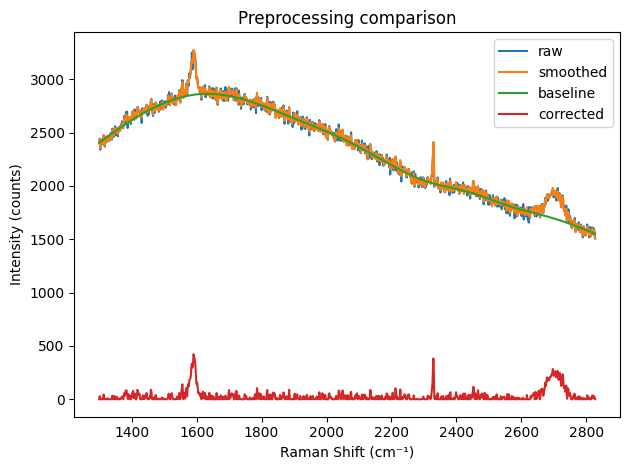


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.47         13.91         385.94         6.95      
2D-1B                2600.00         20.00         0.00           10.00     
2D-1A                2650.00         20.00         51.30          10.00     
2D-2A                2695.40         20.00         268.27         10.00     
2D-2B                2717.85         16.44         162.62         8.22      

Normalized Residual: 0.2692 (0 = perfect fit)


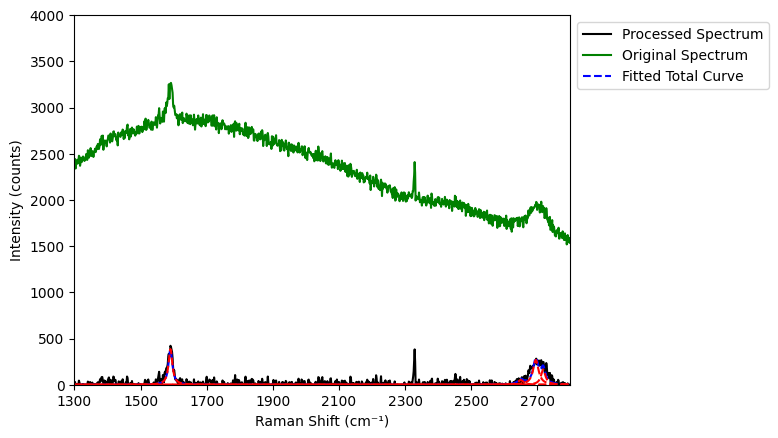

In [3]:
from ramanpl import RamanFit

# Import data from WDF file
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

baseline_setting={"method": "arpls", "lam": 1e6, "niter": 50, "tol": 1e-6}

# Instantiate the RamanFit class
raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method=baseline_setting,
    smoothing=True,
    smooth_order=8
)

# Update the fitting bounds 
bounds_dict = {
    '2D-1B':  ([2600, 0, 0], [2620, 10, 10]),
    '2D-1A':  ([2620, 0, 0], [2650, 10, 20]),
    '2D-2A':  ([2650, 0, 0], [2700, 10, 20]),
    '2D-2B':  ([2700, 0, 0], [2720, 10, 10]),

}
raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )

## 4. Using `airpls` baseline method for background removal
The next cell will demonstrate background subtraction using `airpls` method (a.ka.a. "improved adaptive reweighted penalized least squares"). This method is more effective if peak sit on fluroescent background.

Tuning rules:

- Baseline still high near strong peaks → increase niter (e.g., 120) and/or reduce tol (e.g., 1e-7)

- Baseline becomes unstable → increase lam (e.g., 1e8)

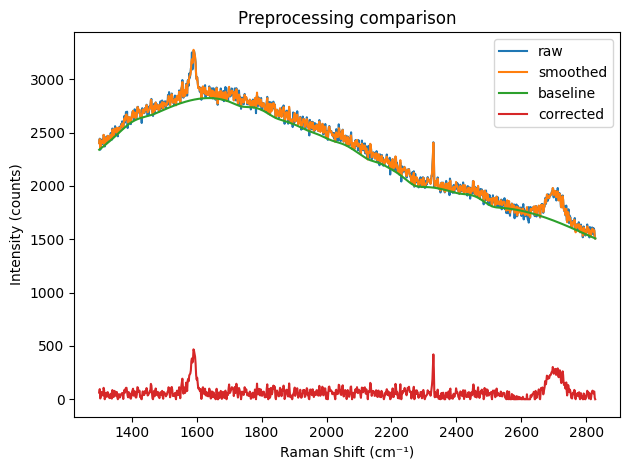


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.24         15.11         394.10         7.56      
2D-1B                2595.00         30.00         8.56           15.00     
2D-1A                2660.00         30.00         29.18          15.00     
2D-2A                2692.90         30.00         227.24         15.00     
2D-2B                2719.35         30.00         198.33         15.00     

Normalized Residual: 0.4633 (0 = perfect fit)


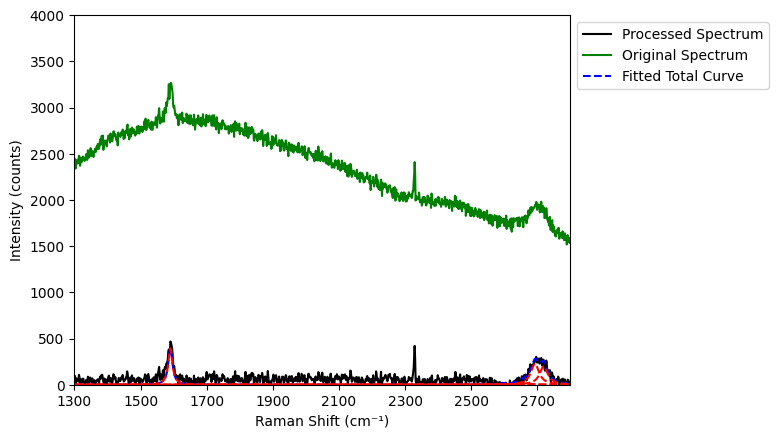

In [4]:
from ramanpl import RamanFit
import numpy as np

spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900)    # Specify the x-axis range to read (in cm^-1)
)

# Exclude major Raman bands from baseline estimation
mask = np.ones_like(wavenumber, dtype=bool)
mask &= ~((wavenumber > 1500) & (wavenumber < 1700))   # G region
mask &= ~((wavenumber > 2320) & (wavenumber < 2380))   # spike region
mask &= ~((wavenumber > 2550) & (wavenumber < 2800))   # 2D region

baseline_setting={
    "method": "airpls",
    "lam": 1e2,
    "niter": 50,
    "tol": 1e-6,
    "mask": mask,
    "min_weight": 1e-3
}


raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method=baseline_setting,
    smoothing=True,
    smooth_order=8
)


# Update the fitting bounds 
bounds_dict = {
    "G":     ([1570, 0, 0], [1610, 15, 20]),   # position, scale, amplitude

    "2D-1B": ([2595, 0, 0], [2625, 15, 20]),
    "2D-1A": ([2620, 0, 0], [2660, 15, 30]),
    "2D-2A": ([2660, 0, 0], [2705, 15, 30]),
    "2D-2B": ([2705, 0, 0], [2735, 15, 20]),
}


raman_fit.update_bounds(**bounds_dict)

# Remove Unecessary peaks
raman_fit.remove_peaks('D')             # 'D' peak around 1400 cm-1 is only needed if you think sample is doped, we remove it in this example

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results with an offset and scale
xlim = [1300, 2800]
raman_fit.plot_fit(params,                          # The Lorentzian parameters fitted 
                   offset=0, scale=1,               # Plot offset or scale of fitted curve relative to raw data
                   x_lim=xlim, y_lim=[0,4000],      # set x-y axis limits
                
                   # set x-axis ticks
                   x_ticks=range(xlim[0],xlim[1],200)
                   )

## 5. Using `gaussian` baseline method for background removal

The Gaussian baseline estimates the background by smoothing the raw spectrum with a
Gaussian kernel of width `gaussian_sigma` (in data points) and subtracting the result.
Because the kernel is wide relative to sharp Raman peaks, the smoothed curve follows the
broad fluorescent envelope while leaving the peaks largely intact.

This method was selected as the **autotune winner** (RMSE = 0.0712) for this spectrum,
outperforming all iterative methods and polynomial fits. It works particularly well here
because the fluorescent background has a smooth, hump-like shape that a broad Gaussian
kernel can reproduce directly, without the iterative reweighting problems that penalise
asls/arpls/airpls when peaks span a large fraction of the spectral window.

**Trade-off:** The Gaussian baseline subtracts a smoothed copy of the raw data. A wide
kernel absorbs some signal from broad peak shoulders, so absolute peak amplitudes after
subtraction will be lower than with a polynomial. Check that peak positions and widths are
physically sensible before using the fitted intensities quantitatively.

Tuning rules:

- Baseline still too high near peaks → increase `gaussian_sigma` (e.g., 50 → 100)

- Baseline cuts too deeply into peak feet → decrease `gaussian_sigma` (e.g., 50 → 20)

- Baseline too flat (misses background curvature) → decrease `gaussian_sigma`

- A good starting point for broad fluorescent backgrounds: `gaussian_sigma` ∈ {30, 50}

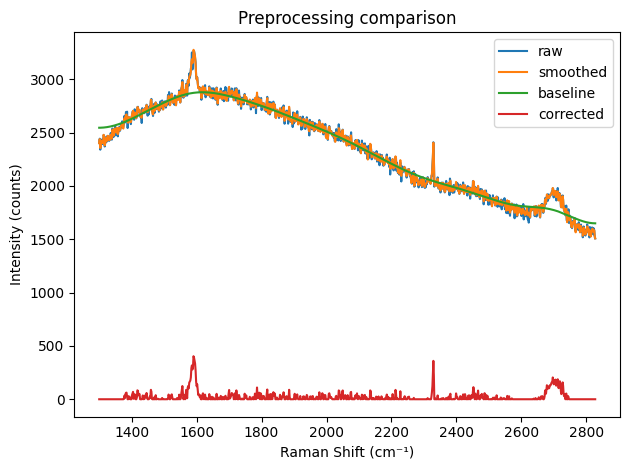


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.51         13.64         376.62         6.82      
2D-1B                2600.00         20.00         0.00           10.00     
2D-1A                2620.00         20.00         0.00           10.00     
2D-2A                2694.05         20.00         163.60         10.00     
2D-2B                2714.60         19.86         129.37         9.93      

Normalized Residual: 0.3021 (0 = perfect fit)


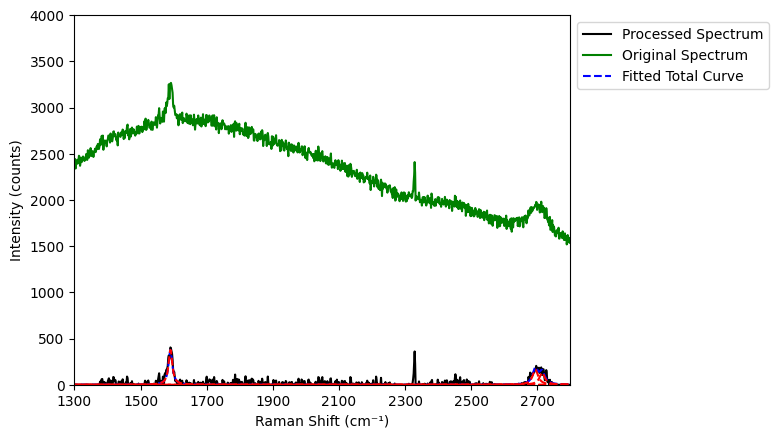

In [5]:
from ramanpl import RamanFit

# Import data
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900)
)

baseline_setting = {"method": "gaussian", "gaussian_sigma": 50}

# Instantiate RamanFit with the Gaussian baseline
raman_fit = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method=baseline_setting,
    smoothing=True,
    smooth_order=8
)

# Update the fitting bounds
bounds_dict = {
    '2D-1B':  ([2600, 0, 0], [2620, 10, 10]),
    '2D-1A':  ([2620, 0, 0], [2650, 10, 20]),
    '2D-2A':  ([2650, 0, 0], [2700, 10, 20]),
    '2D-2B':  ([2700, 0, 0], [2720, 10, 10]),
}
raman_fit.update_bounds(**bounds_dict)

# D peak not expected for this sample
raman_fit.remove_peaks('D')

# Perform the fitting
params, params_cov = raman_fit.fit_spectrum()

# Plot the results
xlim = [1300, 2800]
raman_fit.plot_fit(params,
                   offset=0, scale=1,
                   x_lim=xlim, y_lim=[0, 4000],
                   x_ticks=range(xlim[0], xlim[1], 200))

## Optional: use `autotune_baseline` to select the baseline automatically

Unsure about which baseline method to use? Instead of manually trying each method, `autotune_baseline` scores a grid of candidates
on the spectrum and ranks them by post-fit RMSE. Call `apply_choice(result.winner)` only
if you are satisfied with the winning configuration.

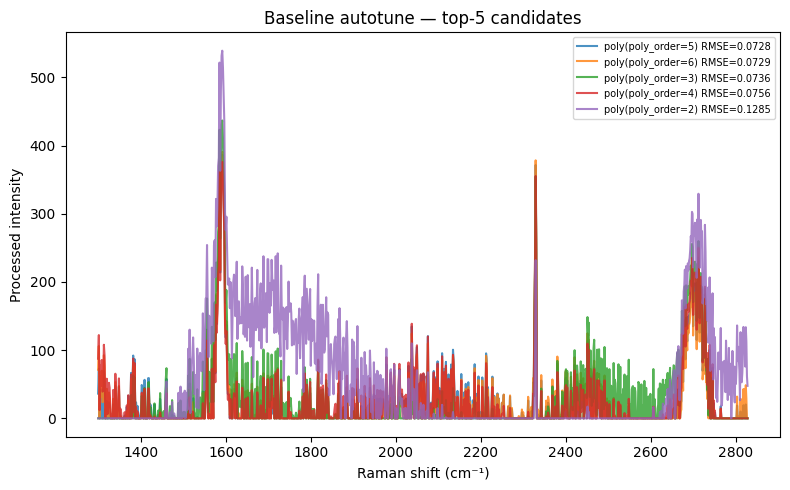

Top-5 ranking:
  #1  poly      {'poly_order': 5}  RMSE=0.0728
  #2  poly      {'poly_order': 6}  RMSE=0.0729
  #3  poly      {'poly_order': 3}  RMSE=0.0736
  #4  poly      {'poly_order': 4}  RMSE=0.0756
  #5  poly      {'poly_order': 2}  RMSE=0.1285

Winner: {'method': 'poly', 'poly_order': 5}


In [6]:
from ramanpl import RamanFit

spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample 532nm 2L-Graphene.txt',
    x_range=(1300, 2900),
)

fit_auto = RamanFit.RamanFit(
    spectra, wavenumber,
    materials=['2L-Gr'],
    substrate=None,
    normalize=False,
    background_remove=True,
    baseline_method={"method": "poly", "poly_order": 4},
    smoothing=True,
    smooth_order=8,
)
fit_auto.update_bounds(
    **{
        '2D-1B': ([2600, 0, 0], [2620, 10, 10]),
        '2D-1A': ([2620, 0, 0], [2650, 10, 20]),
        '2D-2A': ([2650, 0, 0], [2700, 10, 20]),
        '2D-2B': ([2700, 0, 0], [2720, 10, 10]),
    }
)
fit_auto.remove_peaks('D')

# Score a focused grid: poly orders + two airpls lam values
result = fit_auto.autotune_baseline(
    method_grids={
        "poly":   {"poly_order": [1, 2, 3, 4, 5, 6]},
        "airpls": {"lam": [1e-1, 1e0, 1e2, 1e3, 1e4, 1e5], "niter": [50]},
    },
    plot=True,
)

print("Top-5 ranking:")
for rank, entry in enumerate(result.ranking[:5], start=1):
    print(f"  #{rank}  {entry['method']:8s}  {entry['kwargs']}  RMSE={entry['rmse']:.4f}")
print("\nWinner:", result.winner)

Inspect the ranking above. If the winner looks correct, run the cell below to commit it
and refit the spectrum.

Committed baseline: {'method': 'poly', 'poly_order': 5}


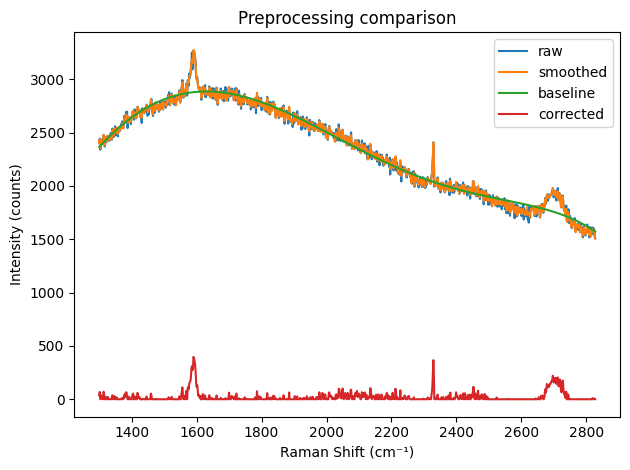


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
G                    1590.57         13.45         375.55         6.73      
2D-1B                2600.00         20.00         0.00           10.00     
2D-1A                2620.00         20.00         0.00           10.00     
2D-2A                2694.78         20.00         193.59         10.00     
2D-2B                2715.84         18.26         138.30         9.13      

Normalized Residual: 0.2925 (0 = perfect fit)


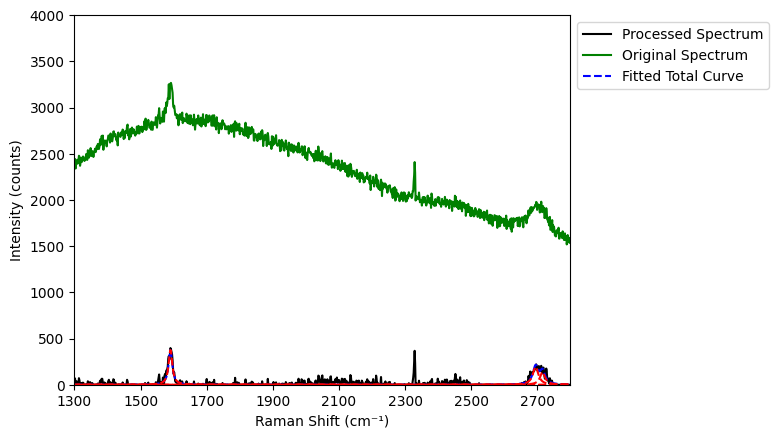

In [7]:
fit_auto.apply_choice(result.winner)
print("Committed baseline:", fit_auto.baseline_method)

params_auto, params_cov_auto = fit_auto.fit_spectrum()

xlim = [1300, 2800]
fit_auto.plot_fit(params_auto, offset=0, scale=1,
                  x_lim=xlim, y_lim=[0, 4000],
                  x_ticks=range(xlim[0], xlim[1], 200))